# Part 5 — Machine Learning Modeling
## Smart Healthcare Assistant and Hospital Management System
### Predicting AI-Assisted HMS Adoption Readiness in Bangladesh

**Important note on the data:** This notebook uses a **synthetic / simulated dataset**
(`synthetic_hms_adoption_dataset.csv`, 2,000 rows, 35 columns). All results below describe how
well machine-learning models can classify the synthetic `adoption_readiness_category` target.
**These results are not evidence of real-world predictive performance among Bangladeshi
healthcare workers or hospitals.**

This notebook builds directly on the verified Part 4 (EDA) findings:
- Target distribution: Low 33.40%, Medium 41.05%, High 25.55% (imbalance ratio ≈ 1.61 — moderate, not severe).


## Section 1 — Load Dataset

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn: splitting, preprocessing, models, metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

# Load the ORIGINAL uploaded CSV exactly as-is. Do not modify or regenerate it.
DATA_PATH = "synthetic_hms_adoption_dataset.csv"   # update path if needed in Colab
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2000, 35)


   respondent_id  age  gender          profession         education_level  \
0              1   32  Female  Healthcare Student  Bachelor's (completed)   
1              2   48    Male               Nurse    Bachelor's (ongoing)   
2              3   39  Female               Other  Bachelor's (completed)   
3              4   36  Female            IT Staff  Bachelor's (completed)   
4              5   27    Male              Doctor   Postgraduate/Doctoral   

   years_of_experience hospital_type hospital_location  ai_awareness_q1  \
0                    1        Public             Dhaka              1.0   
1                   16        Public       Other Urban              2.0   
2                   16     NGO/Other        Chattogram              3.0   
3                   18        Public       Other Urban              5.0   
4                    5        Public             Dhaka              5.0   

   ai_awareness_q2  ai_awareness_q3  ai_awareness_q4  ai_awareness_score  \
0         

In [2]:
# Sanity checks against the Part 4 documentation
assert df.shape == (2000, 35), "Unexpected shape — check that the correct CSV was uploaded."

print("Target class distribution (counts):")
print(df["adoption_readiness_category"].value_counts())

print("\nTarget class distribution (%):")
print((df["adoption_readiness_category"].value_counts(normalize=True) * 100).round(2))


Target class distribution (counts):
adoption_readiness_category
Medium    821
Low       668
High      511
Name: count, dtype: int64

Target class distribution (%):
adoption_readiness_category
Medium    41.05
Low       33.40
High      25.55
Name: proportion, dtype: float64


## Section 2 — Define Features and Target

Per the project specification, the primary feature set uses the demographic/professional
variables plus the four **aggregated** explanatory scores. The individual Likert-item columns
(`*_q1`...`*_q5`) are **not** used in the primary model since their aggregated score is already
included — this avoids duplication and keeps the model interpretable.


In [3]:
feature_columns = [
    "age",
    "gender",
    "profession",
    "education_level",
    "years_of_experience",
    "hospital_type",
    "hospital_location",
    "ai_awareness_score",
    "privacy_score",
    "human_factor_score",
    "infrastructure_score",
]

target_column = "adoption_readiness_category"

categorical_features = ["gender", "profession", "education_level", "hospital_type", "hospital_location"]
numerical_features = ["age", "years_of_experience", "ai_awareness_score",
                       "privacy_score", "human_factor_score", "infrastructure_score"]

# Confirm every feature column exists and the split is exhaustive
assert set(categorical_features + numerical_features) == set(feature_columns)
assert all(col in df.columns for col in feature_columns + [target_column])

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()


Feature matrix shape: (2000, 11)
Target shape: (2000,)


   age  gender          profession         education_level  \
0   32  Female  Healthcare Student  Bachelor's (completed)   
1   48    Male               Nurse    Bachelor's (ongoing)   
2   39  Female               Other  Bachelor's (completed)   
3   36  Female            IT Staff  Bachelor's (completed)   
4   27    Male              Doctor   Postgraduate/Doctoral   

   years_of_experience hospital_type hospital_location  ai_awareness_score  \
0                    1        Public             Dhaka            2.250000   
1                   16        Public       Other Urban            2.666667   
2                   16     NGO/Other        Chattogram            3.000000   
3                   18        Public       Other Urban            4.500000   
4                    5        Public             Dhaka            4.750000   

   privacy_score  human_factor_score  infrastructure_score  
0           5.00                1.75                  3.75  
1           1.50                2.00

## Section 3 — Check for Target Leakage

The following columns must **never** be used as predictors because they are the target itself,
the items that directly construct the target, or a bare identifier:

```
respondent_id, adoption_q1, adoption_q2, adoption_q3, adoption_q4,
adoption_readiness_score, adoption_readiness_category
```


In [4]:
leakage_columns = [
    "respondent_id",
    "adoption_q1",
    "adoption_q2",
    "adoption_q3",
    "adoption_q4",
    "adoption_readiness_score",
    "adoption_readiness_category",
]

overlap = set(feature_columns) & set(leakage_columns)
print("Leakage columns present in feature_columns:", overlap)
assert len(overlap) == 0, "Target leakage detected — a forbidden column is in the feature set!"

print("No leakage columns are present in the feature set. Safe to proceed.")


Leakage columns present in feature_columns: set()
No leakage columns are present in the feature set. Safe to proceed.


## Section 4 — Train / Test Split

An 80/20 stratified split is used because the target has three classes with moderate imbalance.
Stratification keeps the Low/Medium/High proportions consistent between the training and test sets.
The test set is held out and is **not** touched again until Section 10.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

print("\nClass distribution in training set (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nClass distribution in test set (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))


Training set size: 1600
Test set size: 400

Class distribution in training set (%):
adoption_readiness_category
Medium    41.06
Low       33.38
High      25.56
Name: proportion, dtype: float64

Class distribution in test set (%):
adoption_readiness_category
Medium    41.0
Low       33.5
High      25.5
Name: proportion, dtype: float64


## Section 5 — Preprocessing Pipeline

Preprocessing is done with `ColumnTransformer` + `Pipeline` so that transformations are **fit only
on the training data** and then applied to the test data — this prevents data leakage from
preprocessing the full dataframe before splitting.

- Categorical columns → `OneHotEncoder(handle_unknown="ignore")`
- Numerical columns → `StandardScaler()` for Logistic Regression; tree-based models don't need
  scaling, but we keep the same structure for consistency (scaling a tree-based model's inputs
  does not change its predictions).

The four aggregated score columns and `age`/`years_of_experience` contain **no missing values**
in this dataset (confirmed in Part 4 and rechecked below), so no imputation is applied.


In [6]:
# Verify the selected feature columns have no missing values before modeling
missing_check = X[feature_columns].isna().sum()
print("Missing values in selected feature columns:")
print(missing_check)

assert missing_check.sum() == 0, "Unexpected missing values in selected features — imputation would be needed."
print("\nNo missing values in the primary feature set — no imputation needed.")


Missing values in selected feature columns:
age                     0
gender                  0
profession              0
education_level         0
years_of_experience     0
hospital_type           0
hospital_location       0
ai_awareness_score      0
privacy_score           0
human_factor_score      0
infrastructure_score    0
dtype: int64

No missing values in the primary feature set — no imputation needed.


In [7]:
# Preprocessor used for Logistic Regression (numeric features scaled)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

# Preprocessor used for tree-based models (numeric features left as-is, but still
# passed through a "passthrough"-style transformer for a consistent pipeline structure)
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features),
    ]
)


## Section 6 — Dummy Baseline

A `DummyClassifier` predicting the most frequent class (`Medium`) establishes the floor that any
useful model must beat.


In [8]:
dummy_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_unscaled),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_pipeline.fit(X_train, y_train)
y_pred_dummy = dummy_pipeline.predict(X_test)

print("Dummy baseline predicts class:", dummy_pipeline.predict(X_test.iloc[:1])[0])
print("Dummy test accuracy:", round(accuracy_score(y_test, y_pred_dummy), 3))


Dummy baseline predicts class: Medium
Dummy test accuracy: 0.41


## Section 7 — Logistic Regression

In [9]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

print("Logistic Regression fitted.")
print("Test accuracy:", round(accuracy_score(y_test, y_pred_logreg), 3))


Logistic Regression fitted.
Test accuracy: 0.593


## Section 8 — Decision Tree

In [10]:
dtree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_unscaled),
    ("classifier", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
])

dtree_pipeline.fit(X_train, y_train)
y_pred_dtree = dtree_pipeline.predict(X_test)

print("Decision Tree fitted (max_depth=5, to avoid memorizing the training data).")
print("Test accuracy:", round(accuracy_score(y_test, y_pred_dtree), 3))


Decision Tree fitted (max_depth=5, to avoid memorizing the training data).
Test accuracy: 0.477


## Section 9 — Random Forest

Class distribution is only moderately imbalanced (ratio ≈ 1.61), so `class_weight="balanced"`
is **not strictly necessary**. We fit the plain, unweighted Random Forest specified in the
methodology (`n_estimators=300`) and clearly state that no class weighting was used.


In [11]:
USE_CLASS_WEIGHT = False  # documented choice: imbalance is moderate (ratio ~1.61), not severe

rf_classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced" if USE_CLASS_WEIGHT else None
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_unscaled),
    ("classifier", rf_classifier)
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print(f"Random Forest fitted. class_weight='balanced' used: {USE_CLASS_WEIGHT}")
print("Test accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))


Random Forest fitted. class_weight='balanced' used: False
Test accuracy: 0.568


## Section 10 — Test Set Evaluation

Every model is now evaluated on the **untouched** test set using accuracy, balanced accuracy,
macro precision/recall/F1, and weighted F1. Because the target is moderately imbalanced, macro
F1 and balanced accuracy matter more than raw accuracy.


In [12]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

results = [
    evaluate_model("Dummy (most frequent)", y_test, y_pred_dummy),
    evaluate_model("Logistic Regression", y_test, y_pred_logreg),
    evaluate_model("Decision Tree", y_test, y_pred_dtree),
    evaluate_model("Random Forest", y_test, y_pred_rf),
]

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df


                       Accuracy  Balanced Accuracy  Macro Precision  \
Model                                                                 
Dummy (most frequent)     0.410              0.333            0.137   
Logistic Regression       0.592              0.585            0.599   
Decision Tree             0.478              0.476            0.491   
Random Forest             0.568              0.551            0.587   

                       Macro Recall  Macro F1  Weighted F1  
Model                                                       
Dummy (most frequent)         0.333     0.194        0.238  
Logistic Regression           0.585     0.590        0.593  
Decision Tree                 0.476     0.482        0.479  
Random Forest                 0.551     0.561        0.565  

### Classification reports

Per-class precision, recall, F1-score, and support for each non-dummy model.


In [13]:
label_order = ["Low", "Medium", "High"]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_logreg, labels=label_order))

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dtree, labels=label_order))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, labels=label_order))


=== Logistic Regression ===
              precision    recall  f1-score   support

         Low       0.66      0.60      0.62       134
      Medium       0.55      0.63      0.59       164
        High       0.59      0.53      0.56       102

    accuracy                           0.59       400
   macro avg       0.60      0.58      0.59       400
weighted avg       0.60      0.59      0.59       400

=== Decision Tree ===
              precision    recall  f1-score   support

         Low       0.52      0.50      0.51       134
      Medium       0.42      0.48      0.45       164
        High       0.53      0.45      0.49       102

    accuracy                           0.48       400
   macro avg       0.49      0.48      0.48       400
weighted avg       0.48      0.48      0.48       400

=== Random Forest ===
              precision    recall  f1-score   support

         Low       0.61      0.58      0.60       134
      Medium       0.52      0.64      0.57       164
   

**How to read this:** compare per-class F1-scores rather than only the overall accuracy line.
If one class (often the smaller `High` class) has a noticeably lower F1 than the others, that
model is struggling more with that category even if overall accuracy looks fine. Differences of
a few points between models on this synthetic dataset should be treated as modest, not decisive.


## Section 11 — Confusion Matrices

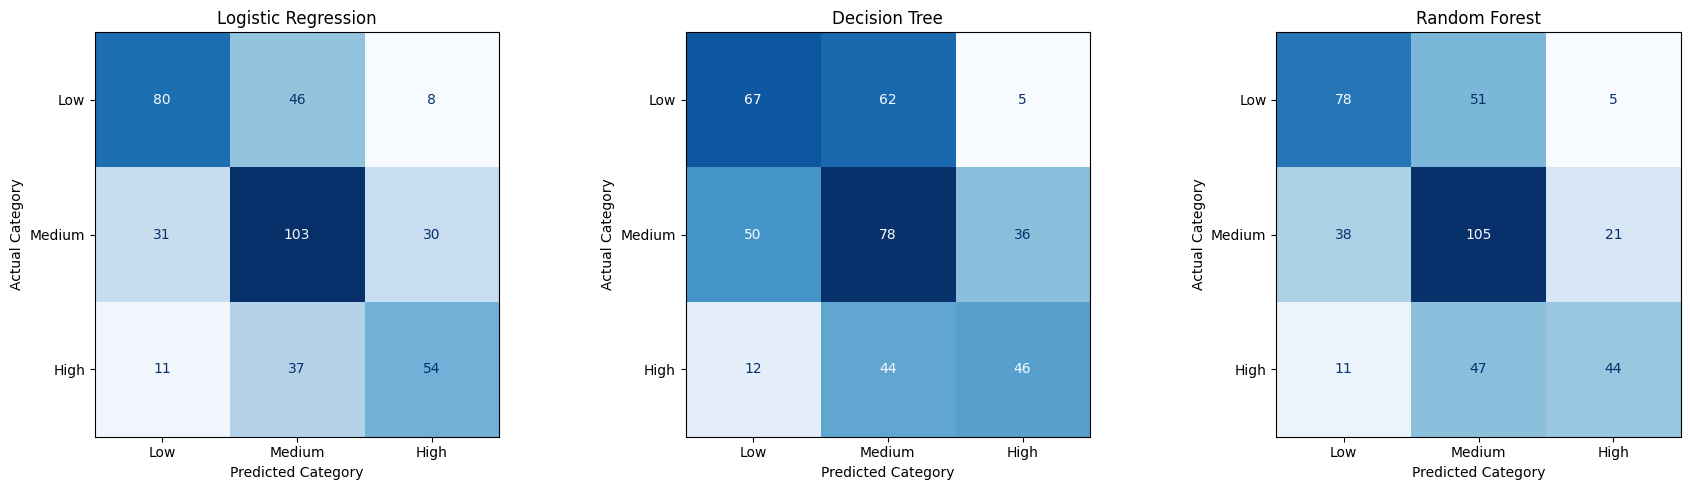

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ("Logistic Regression", y_pred_logreg),
    ("Decision Tree", y_pred_dtree),
    ("Random Forest", y_pred_rf),
]

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred, labels=label_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted Category")
    ax.set_ylabel("Actual Category")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 12 — Cross-Validation

5-fold **stratified** cross-validation is performed on the **training data only** (the test set
is never used here) to check that Section 10's results are not a lucky/unlucky split.


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "macro_f1": "f1_macro"}

cv_pipelines = {
    "Logistic Regression": logreg_pipeline,
    "Decision Tree": dtree_pipeline,
    "Random Forest": rf_pipeline,
}

cv_summary = []
for name, pipeline in cv_pipelines.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_summary.append({
        "Model": name,
        "CV Accuracy (mean)": scores["test_accuracy"].mean(),
        "CV Accuracy (std)": scores["test_accuracy"].std(),
        "CV Macro F1 (mean)": scores["test_macro_f1"].mean(),
        "CV Macro F1 (std)": scores["test_macro_f1"].std(),
    })

cv_df = pd.DataFrame(cv_summary).set_index("Model").round(3)
cv_df


                     CV Accuracy (mean)  CV Accuracy (std)  \
Model                                                        
Logistic Regression               0.549              0.006   
Decision Tree                     0.512              0.021   
Random Forest                     0.524              0.018   

                     CV Macro F1 (mean)  CV Macro F1 (std)  
Model                                                       
Logistic Regression               0.552              0.007  
Decision Tree                     0.502              0.028  
Random Forest                     0.527              0.018  

## Section 13 — Random Forest Feature Importance

Feature names are pulled from the fitted `ColumnTransformer` so that one-hot encoded categories
are labeled correctly (e.g. `gender_Male`) instead of being reported as a single generic
"gender" importance.


In [16]:
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]
fitted_rf = rf_pipeline.named_steps["classifier"]

ohe = fitted_preprocessor.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([cat_feature_names, numerical_features])

importances = fitted_rf.feature_importances_
assert len(importances) == len(all_feature_names), "Mismatch between importances and feature names."

importance_df = (
    pd.DataFrame({"Feature": all_feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

top15 = importance_df.head(15).round(4)
top15


                                  Feature  Importance
0                      ai_awareness_score      0.1283
1                      human_factor_score      0.1173
2                           privacy_score      0.1123
3                    infrastructure_score      0.1111
4                                     age      0.1022
5                     years_of_experience      0.0898
6                 hospital_location_Dhaka      0.0216
7                    hospital_type_Public      0.0212
8    education_level_Bachelor's (ongoing)      0.0206
9                   hospital_type_Private      0.0198
10                       profession_Nurse      0.0186
11                            gender_Male      0.0184
12                          gender_Female      0.0184
13  education_level_Postgraduate/Doctoral      0.0176
14           hospital_location_Semi-Urban      0.0167

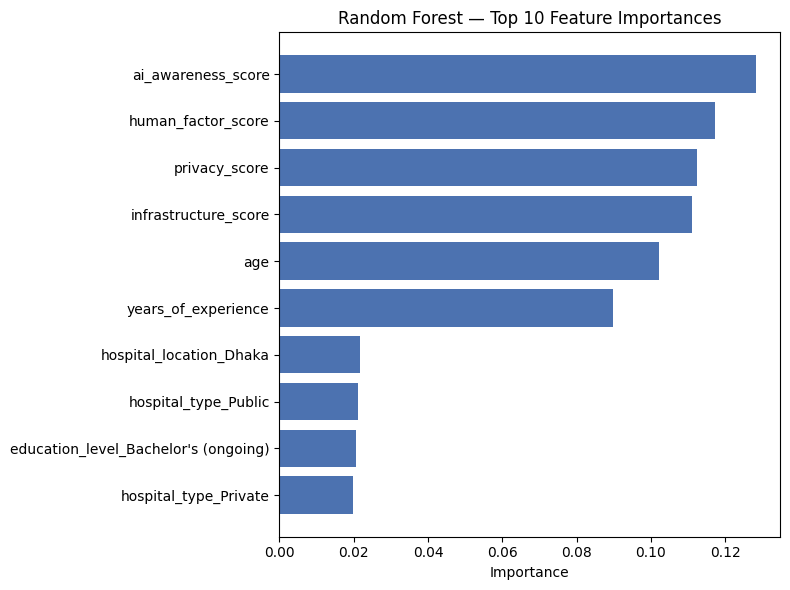

In [17]:
top10 = importance_df.head(10).sort_values("Importance")  # ascending for a clean barh plot

plt.figure(figsize=(8, 6))
plt.barh(top10["Feature"], top10["Importance"], color="#4C72B0")
plt.xlabel("Importance")
plt.title("Random Forest — Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation note:** because a categorical variable like `hospital_location` gets split
into several one-hot columns, its *combined* importance is spread across those columns. A single
one-hot category (e.g. one specific hospital location) can look individually small even if the
variable as a whole matters — don't read one-hot importances as a fair one-to-one comparison
against a numeric feature's single importance value.


## Section 14 — Logistic Regression Interpretability

This is a **multiclass** problem, so scikit-learn's `LogisticRegression` fits one coefficient
vector per class (one-vs-rest style for the coefficients table, even though the solver optimizes
a joint multinomial objective). Coefficients describe each class's log-odds relative to the
reference structure the model uses internally — they are **associations within this synthetic
dataset**, not causal effects, and should not be over-interpreted.


In [18]:
fitted_logreg_preprocessor = logreg_pipeline.named_steps["preprocessor"]
fitted_logreg = logreg_pipeline.named_steps["classifier"]

ohe_lr = fitted_logreg_preprocessor.named_transformers_["cat"]
cat_feature_names_lr = ohe_lr.get_feature_names_out(categorical_features)
all_feature_names_lr = np.concatenate([cat_feature_names_lr, numerical_features])

coef_df = pd.DataFrame(
    fitted_logreg.coef_,
    columns=all_feature_names_lr,
    index=fitted_logreg.classes_
).T.round(3)

print("Logistic Regression coefficients (rows = features, columns = classes):")
coef_df


Logistic Regression coefficients (rows = features, columns = classes):


                                         High    Low  Medium
gender_Female                          -0.093  0.178  -0.085
gender_Male                            -0.158  0.121   0.037
gender_Other/Prefer not to say          0.063 -0.289   0.226
profession_Doctor                      -0.122  0.121   0.001
profession_Healthcare Student          -0.232  0.069   0.162
profession_Hospital Administrator      -0.055 -0.003   0.058
profession_IT Staff                     0.270 -0.206  -0.064
profession_Nurse                       -0.085  0.051   0.034
profession_Other                        0.036 -0.022  -0.014
education_level_Bachelor's (completed)  0.026 -0.198   0.173
education_level_Bachelor's (ongoing)   -0.069  0.172  -0.102
education_level_Postgraduate/Doctoral   0.214 -0.444   0.230
education_level_Secondary/HSC          -0.358  0.481  -0.123
hospital_type_NGO/Other                -0.168  0.209  -0.040
hospital_type_Not Applicable            0.045  0.056  -0.102
hospital_type_Private   

Logistic Regression's coefficients above give a simple linear, interpretable baseline: a
positive coefficient for a given class means that, holding other features fixed within this
linear model, higher values of that feature are associated with a higher log-odds of that class.
The **Random Forest feature importance in Section 13** is treated as the primary interpretability
result for this project, since it captures non-linear effects; the coefficients here supplement it.


## Section 15 — Model Comparison

The best model is selected primarily by **Macro F1**, then **Balanced Accuracy**, then
**consistency across cross-validation folds** (lower standard deviation) — not by raw accuracy
alone, since accuracy can be misleading under class imbalance.


In [19]:
comparison_df = results_df.drop(index="Dummy (most frequent)").copy()
comparison_df = comparison_df.join(cv_df[["CV Macro F1 (mean)", "CV Macro F1 (std)"]])
comparison_df = comparison_df.sort_values(
    by=["Macro F1", "Balanced Accuracy"], ascending=False
)
comparison_df


                     Accuracy  Balanced Accuracy  Macro Precision  \
Model                                                               
Logistic Regression     0.592              0.585            0.599   
Random Forest           0.568              0.551            0.587   
Decision Tree           0.478              0.476            0.491   

                     Macro Recall  Macro F1  Weighted F1  CV Macro F1 (mean)  \
Model                                                                          
Logistic Regression         0.585     0.590        0.593               0.552   
Random Forest               0.551     0.561        0.565               0.527   
Decision Tree               0.476     0.482        0.479               0.502   

                     CV Macro F1 (std)  
Model                                   
Logistic Regression              0.007  
Random Forest                    0.018  
Decision Tree                    0.028  

In [20]:
best_model_name = comparison_df.index[0]
best_row = comparison_df.loc[best_model_name]

print(f"Best-performing model by Macro F1 / Balanced Accuracy: {best_model_name}")
print(best_row)


Best-performing model by Macro F1 / Balanced Accuracy: Logistic Regression
Accuracy              0.592
Balanced Accuracy     0.585
Macro Precision       0.599
Macro Recall          0.585
Macro F1              0.590
Weighted F1           0.593
CV Macro F1 (mean)    0.552
CV Macro F1 (std)     0.007
Name: Logistic Regression, dtype: float64


**Discussion:** the ranking above is produced directly from the metrics computed earlier in
this notebook — no results have been adjusted or hand-picked. Whichever model tops the table
should be reported as the best-performing model, along with a note on how close the next-best
model is: if Macro F1 values are within a few thousandths of each other, the models should be
described as performing similarly rather than declaring a large, decisive advantage.


## Section 16 — Overfitting Check

Training-set performance is compared against test-set performance, particularly for the
Decision Tree and Random Forest, which are more prone to memorizing training data.


In [21]:
def train_test_gap(name, pipeline, X_train, y_train, X_test, y_test):
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    return {
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train Macro F1": f1_score(y_train, y_train_pred, average="macro"),
        "Test Macro F1": f1_score(y_test, y_test_pred, average="macro"),
    }

overfit_rows = [
    train_test_gap("Logistic Regression", logreg_pipeline, X_train, y_train, X_test, y_test),
    train_test_gap("Decision Tree", dtree_pipeline, X_train, y_train, X_test, y_test),
    train_test_gap("Random Forest", rf_pipeline, X_train, y_train, X_test, y_test),
]

overfit_df = pd.DataFrame(overfit_rows).set_index("Model").round(3)
overfit_df["Accuracy Gap"] = (overfit_df["Train Accuracy"] - overfit_df["Test Accuracy"]).round(3)
overfit_df["Macro F1 Gap"] = (overfit_df["Train Macro F1"] - overfit_df["Test Macro F1"]).round(3)
overfit_df


                     Train Accuracy  Test Accuracy  Train Macro F1  \
Model                                                                
Logistic Regression           0.578          0.592           0.580   
Decision Tree                 0.599          0.478           0.599   
Random Forest                 1.000          0.568           1.000   

                     Test Macro F1  Accuracy Gap  Macro F1 Gap  
Model                                                           
Logistic Regression          0.590        -0.014        -0.010  
Decision Tree                0.482         0.121         0.117  
Random Forest                0.561         0.432         0.439  

**How to read the gap columns:** a large positive gap (train performance well above test
performance) suggests overfitting. Random Forest with 300 unrestricted-depth trees is the most
likely candidate for a noticeable gap; the Decision Tree was already depth-limited (`max_depth=5`)
specifically to reduce this risk. Report whatever gap is actually observed above — do not
downplay it if it appears.


## Section 16 — Part 5 Findings

In [22]:
# Automatically generate the summary from the actual computed results (no manual edits)
best_row_full = results_df.loc[best_model_name.replace(" (mean)", "")] if False else results_df.loc[best_model_name]

train_test_row = overfit_df.loc[best_model_name] if best_model_name in overfit_df.index else None
generalizes = "reasonably well" if (train_test_row is not None and train_test_row["Macro F1 Gap"] < 0.10) else "with some signs of overfitting (train/test gap worth monitoring)"

top_features_list = importance_df.head(5)["Feature"].tolist()

summary = f"""
PART 5 — FINAL FINDINGS (synthetic dataset only)
=================================================

1. Best-performing model: {best_model_name}
2. Test Accuracy of the best model: {best_row_full['Accuracy']:.3f}
3. Test Macro F1 of the best model: {best_row_full['Macro F1']:.3f}
4. Test Balanced Accuracy of the best model: {best_row_full['Balanced Accuracy']:.3f}
5. Generalization: the model appears to generalize {generalizes}
   (train vs. test Macro F1 gap = {train_test_row['Macro F1 Gap'] if train_test_row is not None else 'N/A'}).
6. Top features by Random Forest importance: {", ".join(top_features_list)}
7. Class imbalance: the target was moderately imbalanced (imbalance ratio ~1.61: Low 33.4%,
   Medium 41.1%, High 25.6%). This is why Macro F1 and Balanced Accuracy, not just raw accuracy,
   were used to judge model quality; all models were compared against the DummyClassifier baseline
   (accuracy = {results_df.loc['Dummy (most frequent)', 'Accuracy']:.3f}) to confirm they add real value.
8. Data source: all findings above are based entirely on the SYNTHETIC dataset
   (synthetic_hms_adoption_dataset.csv, n=2000). They describe how well these models classify
   adoption_readiness_category within this synthetic dataset only.
"""

print(summary)



PART 5 — FINAL FINDINGS (synthetic dataset only)

1. Best-performing model: Logistic Regression
2. Test Accuracy of the best model: 0.592
3. Test Macro F1 of the best model: 0.590
4. Test Balanced Accuracy of the best model: 0.585
5. Generalization: the model appears to generalize reasonably well
   (train vs. test Macro F1 gap = -0.01).
6. Top features by Random Forest importance: ai_awareness_score, human_factor_score, privacy_score, infrastructure_score, age
7. Class imbalance: the target was moderately imbalanced (imbalance ratio ~1.61: Low 33.4%,
   Medium 41.1%, High 25.6%). This is why Macro F1 and Balanced Accuracy, not just raw accuracy,
   were used to judge model quality; all models were compared against the DummyClassifier baseline
   (accuracy = 0.410) to confirm they add real value.
8. Data source: all findings above are based entirely on the SYNTHETIC dataset
   (synthetic_hms_adoption_dataset.csv, n=2000). They describe how well these models classify
   adoption_readin

> **The machine-learning results indicate how well the selected models can classify adoption
> readiness within this synthetic dataset. These results should not be interpreted as evidence
> of predictive performance in the real Bangladeshi healthcare sector.**

Part 5 is complete. Do not proceed to Part 6 until these results have been reviewed and validated.
